In [1]:
import matplotlib.pyplot as plt
import scienceplots
import pandas as pd
import glob
import os

plt.style.use(['science'])

pra_params = {
    'font.size': 14,
    'text.usetex': True,
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman'],
}

plt.rcParams.update(pra_params)

In [2]:
file_paths = glob.glob('*.csv')
data_dict = {}

for path in file_paths:
    file_name = os.path.basename(path)
    label = os.path.splitext(file_name)[0]
    data_dict[label] = pd.read_csv(path)

In [3]:
d_lst = data_dict['hybrid_p_l_0_01']['distance_km'].to_numpy()

sk_level_0_total = data_dict['hybrid_p_l_0_01']['keyrate_bps_level_0'].to_numpy()
sk_level_0_W = data_dict['hybrid_p_l_0_01']['keyrate_W_bps_level_0'].to_numpy()
sk_level_0_GHZ = data_dict['hybrid_p_l_0_01']['keyrate_GHZ_bps_level_0'].to_numpy()

sk_level_1_total = data_dict['hybrid_p_l_0_01']['keyrate_bps_level_1'].to_numpy()
sk_level_1_W = data_dict['hybrid_p_l_0_01']['keyrate_W_bps_level_1'].to_numpy()
sk_level_1_GHZ = data_dict['hybrid_p_l_0_01']['keyrate_GHZ_bps_level_1'].to_numpy()

sk_level_2_total = data_dict['hybrid_p_l_0_01']['keyrate_bps_level_2'].to_numpy()
sk_level_2_W = data_dict['hybrid_p_l_0_01']['keyrate_W_bps_level_2'].to_numpy()
sk_level_2_GHZ = data_dict['hybrid_p_l_0_01']['keyrate_GHZ_bps_level_2'].to_numpy()

rel_W_level_0 = sk_level_0_W / sk_level_0_total
rel_GHZ_level_0 = sk_level_0_GHZ / sk_level_0_total

rel_W_level_1 = sk_level_1_W / sk_level_1_total
rel_GHZ_level_1 = sk_level_1_GHZ / sk_level_1_total

rel_W_level_2 = sk_level_2_W / sk_level_2_total
rel_GHZ_level_2 = sk_level_2_GHZ / sk_level_2_total

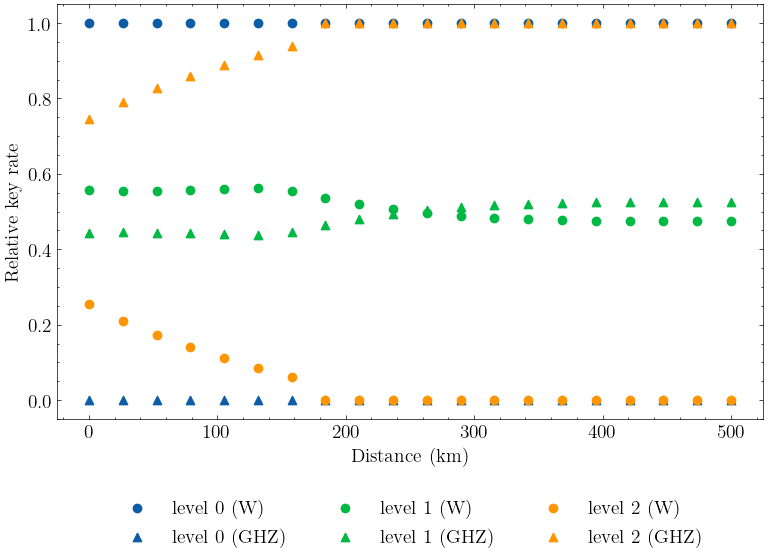

In [4]:
plt.figure(figsize=(8, 6))
plt.xlabel("Distance (km)")
plt.ylabel("Relative key rate")
plt.scatter(d_lst, rel_W_level_0, label = 'level 0 (W)', marker='o', c='C0')
plt.scatter(d_lst, rel_GHZ_level_0, label = 'level 0 (GHZ)', marker='^', c='C0')

plt.scatter(d_lst, rel_W_level_1, label = 'level 1 (W)', marker='o', c='C1')
plt.scatter(d_lst, rel_GHZ_level_1, label = 'level 1 (GHZ)', marker='^', c='C1')

plt.scatter(d_lst, rel_W_level_2, label = 'level 2 (W)', marker='o', c='C2')
plt.scatter(d_lst, rel_GHZ_level_2, label = 'level 2 (GHZ)', marker='^', c='C2')
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=3,
    frameon=False,  # optional: removes legend border
)
plt.tight_layout()  # ensures the legend isn't cut off when saving/displaying

plt.savefig('rate_relative_hybrid.pdf', bbox_inches='tight')
